In [ ]:
import numpy as np
import pandas as pd

# === 1. Baca data dan bangun matriks adjacency ===
file_path = "/content/semua_link.csv"

# Lewati baris komentar yang diawali '#'
# Baca CSV dengan separator koma dan lewati header (pertama baris)
edges = pd.read_csv(file_path, sep=',', comment='#', names=['From', 'To'], skiprows=1)

# Tentukan jumlah node
nodes = pd.Index(sorted(set(edges['From']).union(edges['To'])))
n = len(nodes)
print(f"Jumlah node: {n}")

# Buat mapping node → index
node_to_index = {node: i for i, node in enumerate(nodes)}

# Bangun matriks adjacency (sparse)
A = np.zeros((n, n), dtype=float)
for _, row in edges.iterrows():
    i = node_to_index[row['From']]
    j = node_to_index[row['To']]
    A[j, i] = 1   # Kolom j, baris i (arah From → To)

# === 2. Normalisasi kolom (matriks stokastik) ===
col_sums = A.sum(axis=0)
for j in range(n):
    if col_sums[j] == 0:
        A[:, j] = 1.0 / n    # Dangling node → teleportasi penuh
    else:
        A[:, j] /= col_sums[j]

# === 3. Inisialisasi PageRank ===
r = np.ones(n) / n

# === 4. Iterasi hingga konvergen ===
d = 0.85     # faktor damping
epsilon = 1e-6
converged = False
iteration = 0

while not converged:
    r_new = d * A @ r + (1 - d) / n
    diff = np.linalg.norm(r_new - r, 1)
    iteration += 1
    print(f"Iterasi {iteration}:  = {diff:.8f}")
    if diff < epsilon:
        converged = True
    r = r_new

# === 5. Tampilkan hasil ===
pagerank_df = pd.DataFrame({
    'Node': nodes,
    'PageRank': r
}).sort_values(by='PageRank', ascending=False)

print("\nTop 5 node dengan PageRank tertinggi:")
print(pagerank_df.head(5))

Jumlah node: 131
Iterasi 1:  = 0.20641431
Iterasi 2:  = 0.05763070
Iterasi 3:  = 0.01609044
Iterasi 4:  = 0.00449244
Iterasi 5:  = 0.00125429
Iterasi 6:  = 0.00035020
Iterasi 7:  = 0.00009777
Iterasi 8:  = 0.00002730
Iterasi 9:  = 0.00000762
Iterasi 10:  = 0.00000213
Iterasi 11:  = 0.00000059

Top 5 node dengan PageRank tertinggi:
                                                  Node  PageRank
0                      http://himatif.trunojoyo.ac.id/   0.01059
5           https://informatika.trunojoyo.ac.id/berita   0.01059
4                 https://informatika.trunojoyo.ac.id/   0.01059
113  https://informatika.trunojoyo.ac.id/unit-kegia...   0.01059
99   https://informatika.trunojoyo.ac.id/laboratori...   0.01059


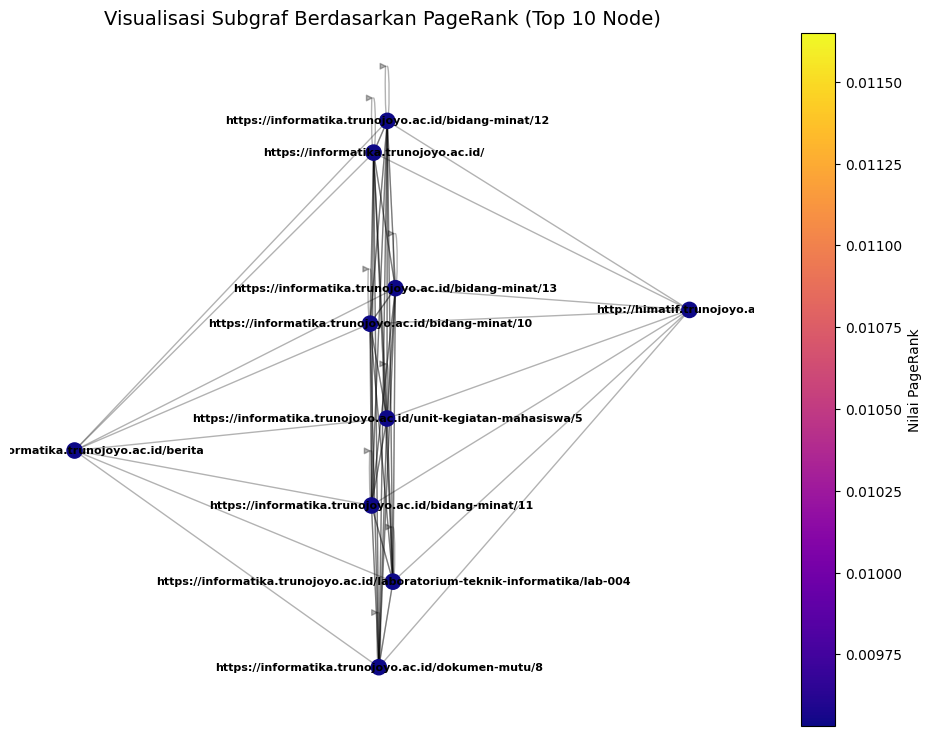

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  # Import numpy for array operations

# === 1. Buat Graph dari data ===
file_path = "/content/semua_link.csv"
edges = pd.read_csv(file_path, sep=',', comment='#', names=['From', 'To'], skiprows=1)

G = nx.DiGraph()
G.add_edges_from(edges.itertuples(index=False, name=None))

# === PageRank Calculation ===
nodes = pd.Index(sorted(set(edges['From']).union(edges['To'])))
n = len(nodes)
node_to_index = {node: i for i, node in enumerate(nodes)}

A = np.zeros((n, n), dtype=float)
for _, row in edges.iterrows():
    i = node_to_index[row['From']]
    j = node_to_index[row['To']]
    A[j, i] = 1

col_sums = A.sum(axis=0)
for j in range(n):
    if col_sums[j] == 0:
        A[:, j] = 1.0 / n
    else:
        A[:, j] /= col_sums[j]

r = np.ones(n) / n
d = 0.85
epsilon = 1e-6
converged = False
iteration = 0

while not converged:
    r_new = d * A @ r + (1 - d) / n
    diff = np.linalg.norm(r_new - r, 1)
    iteration += 1
    if diff < epsilon:
        converged = True
    r = r_new

pagerank_df = pd.DataFrame({
    'Node': nodes,
    'PageRank': r
}).sort_values(by='PageRank', ascending=False)

# === 2. Ambil 10 node dengan PageRank tertinggi ===
top_nodes = pagerank_df.head(10)['Node'].tolist()
H = G.subgraph(top_nodes).copy()

pr_sub = dict(zip(pagerank_df['Node'], pagerank_df['PageRank']))
node_colors = [pr_sub.get(n, 0) for n in H.nodes()]

# === 3. Visualisasi graf dengan label ===
fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(H, k=0.35, seed=42)

# Node dan edge
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    node_size=120,
    ax=ax
)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=False, ax=ax)

# === Tambahkan label node ===
nx.draw_networkx_labels(
    H, pos,
    font_size=8,
    font_color='black',
    font_weight='bold',
    ax=ax
)

ax.set_title("Visualisasi Subgraf Berdasarkan PageRank (Top 10 Node)", fontsize=14)
ax.axis("off")

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma)
sm.set_array(node_colors)
plt.colorbar(sm, label="Nilai PageRank", ax=ax)

plt.show()
